<a href="https://colab.research.google.com/github/RajKumar0429/Capstone__Project/blob/main/Cleaned_housing_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as	pd
import numpy as np
import	matplotlib.pyplot as plt
import	seaborn as sns

## 1.Load cleaned_data.csv

In [2]:
df=pd.read_csv("/content/cleaned_housing_data.csv")

In [3]:
df.shape

(50000, 19)

Feature matrix X:


In [4]:
X=df.drop(columns=['Price_in_Lakhs'])
y_reg=df['Price_in_Lakhs']

In [5]:
X.shape

(50000, 18)

In [6]:
y_clf = (y_reg > y_reg.median()).astype(int)

Classification label y_clf: a binary column derived by binarizing y_reg at its median (y_clf = (y_reg > y_reg.median()).astype(int)) or another natural binary column in the dataset. State both label definitions clearly in the README.

## 2. Encode categorical columns:

In [7]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [8]:
Lab=LabelEncoder()

In [9]:
X["Public_Transport_Accessibility"]=Lab.fit_transform(X["Public_Transport_Accessibility"])
X["Parking_Space"]=Lab.fit_transform(X["Parking_Space"])
X["Security"]=Lab.fit_transform(X["Security"])

In [10]:
X_encoded = pd.get_dummies(
    X[['State','City','Property_Type',"Furnished_Status","Facing","Amenities","Owner_Type","Availability_Status"]],
        dtype='int',sparse=True,
    drop_first=True
)

In [11]:
X_encoded.shape

(50000, 394)

In [12]:
X.drop(columns=['State','City','Property_Type',"Furnished_Status","Facing","Amenities","Owner_Type","Availability_Status"],inplace=True)

In [13]:
X.head(5)

,BHK,Size_in_SqFt,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security
0,1,4740,22,1,35,10,3,0,0,0
1,3,2364,21,20,17,8,1,1,0,1
2,2,3642,19,27,28,9,8,1,1,0
3,2,2741,21,26,34,5,7,0,1,1
4,4,4823,3,2,23,4,9,1,0,1


In [14]:
X_final=pd.concat([X.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

In [15]:
X_final.head(3)

,BHK,Size_in_SqFt,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,...,"Amenities_Pool, Playground, Garden, Gym","Amenities_Pool, Playground, Garden, Gym, Clubhouse","Amenities_Pool, Playground, Gym","Amenities_Pool, Playground, Gym, Clubhouse","Amenities_Pool, Playground, Gym, Clubhouse, Garden","Amenities_Pool, Playground, Gym, Garden","Amenities_Pool, Playground, Gym, Garden, Clubhouse",Owner_Type_Builder,Owner_Type_Owner,Availability_Status_Under_Construction
0,1,4740,22,1,35,10,3,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,3,2364,21,20,17,8,1,1,0,1,...,0,0,0,0,0,0,0,1,0,1
2,2,3642,19,27,28,9,8,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Leak-free train-test split and scaling:

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_reg, test_size=0.2, random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 404), (10000, 404), (40000,), (10000,))



*   Scaling




In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [19]:
scaler.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


StandardScaler()

In [20]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


## 4. Regression model — Linear Regression:

In [21]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [22]:
LR.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
y_pred = LR.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score


print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R^2 Score: {r2_score(y_test, y_pred):.2f}")

Mean Squared Error: 19912.90
R^2 Score: -0.01


In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Fit model (example)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Build DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Coefficient": model.coef_
})

# Add absolute values
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute value
coef_df_sorted = coef_df.sort_values(by="AbsCoefficient", ascending=False)

# Print all coefficients
print(coef_df)

# Identify top 3 features with largest absolute coefficients
top3 = coef_df_sorted.head(3)
print("\nTop 3 features with largest absolute coefficients:")
for _, row in top3.iterrows():
    print(f"Feature: {row['Feature']} | Coefficient: {row['Coefficient']:.2f}")

                                               Feature  Coefficient  \
0                                                  BHK     0.128372   
1                                         Size_in_SqFt    -1.167100   
2                                             Floor_No     0.032538   
3                                         Total_Floors    -1.454877   
4                                      Age_of_Property    -0.709155   
..                                                 ...          ...   
399            Amenities_Pool, Playground, Gym, Garden    -0.614118   
400  Amenities_Pool, Playground, Gym, Garden, Clubh...    -0.628405   
401                                 Owner_Type_Builder     0.165291   
402                                   Owner_Type_Owner    -0.412450   
403             Availability_Status_Under_Construction     0.548371   

     AbsCoefficient  
0          0.128372  
1          1.167100  
2          0.032538  
3          1.454877  
4          0.709155  
..             

In [26]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Plain Linear Regression


mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

# Ridge Regression (alpha=1.0)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print comparison
print("Linear Regression - MSE:", mse_lr, "R²:", r2_lr)
print("Ridge Regression   - MSE:", mse_ridge, "R²:", r2_ridge)

Linear Regression - MSE: 19912.900890603356 R²: -0.010191610533669015
Ridge Regression   - MSE: 19912.89142042317 R²: -0.010191130106601554


## 5. Classification model — Logistic Regression:

In [27]:
y_clf.value_counts()

,count
Price_in_Lakhs,
1,25000
0,25000


In [28]:
X_final.shape

(50000, 404)

In [29]:
from sklearn .model_selection import train_test_split
X_train_clf,X_test_clf,y_train_clf,y_test_clf=train_test_split(X_final,y_clf,test_size=0.2,random_state=42,stratify=y_clf)

In [30]:
scaler.fit(X_train_clf)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


StandardScaler()

In [31]:
X_train_clf_scaled=scaler.transform(X_train_clf)
X_test_clf_scaled=scaler.transform(X_test_clf)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [32]:
from sklearn.linear_model import LogisticRegression
Lr=LogisticRegression(max_iter=1000)

In [33]:
Lr.fit(X_train_clf_scaled,y_train_clf)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_clf=Lr.predict(X_test_clf)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [35]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report

In [36]:
print(f"accuracy_score:{accuracy_score(y_pred_clf,y_test_clf)}")
print(f"f1_score:{f1_score(y_pred_clf,y_test_clf)}")
print(f"precision_score:{precision_score(y_pred_clf,y_test_clf)}")
print(f"recall_score:{recall_score(y_pred_clf,y_test_clf)}")
print(f"confusion_matrix:\n{confusion_matrix(y_pred_clf,y_test_clf)}")
print(f"classification_report:{classification_report(y_pred_clf,y_test_clf)}")

accuracy_score:0.5
f1_score:0.0
precision_score:0.0
recall_score:0.0
confusion_matrix:
[[5000 5000]
 [   0    0]]
classification_report:              precision    recall  f1-score   support

           0       1.00      0.50      0.67     10000
           1       0.00      0.00      0.00         0

    accuracy                           0.50     10000
   macro avg       0.50      0.25      0.33     10000
weighted avg       1.00      0.50      0.67     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

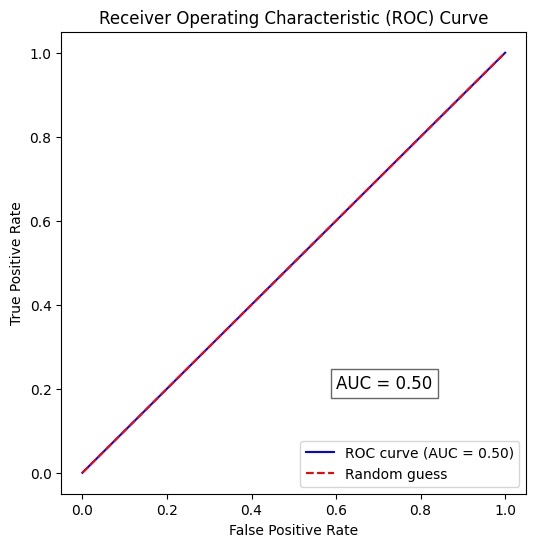

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


# 1. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_clf)

# 2. Compute AUC
auc_score = roc_auc_score(y_test_clf, y_pred_clf)

# 3. Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--", label="Random guess")

# 4. Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")

# 5. Annotate AUC value on the plot
plt.text(0.6, 0.2, f"AUC = {auc_score:.2f}", fontsize=12, bbox=dict(facecolor="white", alpha=0.6))

plt.show()

## 5(b) Decision-threshold sensitivity.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicted probabilities for the positive class
y_proba = Lr.predict_proba(X_test_clf)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0.30, 0.71, 0.10)

results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    prec = precision_score(y_pred_clf,y_test_clf, pos_label=1)
    rec  = recall_score(y_pred_clf,y_test_clf, pos_label=1)
    f1   = f1_score(y_pred_clf,y_test_clf, pos_label=1)
    results.append([t, prec, rec, f1])

# Convert to DataFrame for tabular display
results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   Threshold  Precision  Recall   F1
0        0.3        0.0     0.0  0.0
1        0.4        0.0     0.0  0.0
2        0.5        0.0     0.0  0.0
3        0.6        0.0     0.0  0.0
4        0.7        0.0     0.0  0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

## 6. Regularization experiment on Logistic Regression:

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Baseline model (C=1.0)
log_reg_base = LogisticRegression(C=1.0, solver="liblinear", random_state=42)
log_reg_base.fit(X_train_clf_scaled,y_train_clf)
y_pred_base = log_reg_base.predict(X_test_clf)
y_proba_base = log_reg_base.predict_proba(X_test_clf)[:, 1]

prec_base = precision_score(y_test_clf, y_pred_base)
rec_base  = recall_score(y_test_clf, y_pred_base)
auc_base  = roc_auc_score(y_test_clf, y_proba_base)

# Strongly regularized model (C=0.01)
log_reg_reg = LogisticRegression(C=0.01, solver="liblinear", random_state=42)
log_reg_reg.fit(X_train_scaled, y_train_clf)
y_pred_reg = log_reg_reg.predict(X_test_clf)
y_proba_reg = log_reg_reg.predict_proba(X_test_clf)[:, 1]

prec_reg = precision_score(y_test_clf, y_pred_reg)
rec_reg  = recall_score(y_test_clf, y_pred_reg)
auc_reg  = roc_auc_score(y_test_clf, y_proba_reg)

# Comparison table
import pandas as pd
results = pd.DataFrame({
    "Model": ["LogReg (C=1.0)", "LogReg (C=0.01)"],
    "Precision": [prec_base, prec_reg],
    "Recall": [rec_base, rec_reg],
    "AUC": [auc_base, auc_reg]
})
print(results)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

             Model  Precision  Recall       AUC
0   LogReg (C=1.0)        0.0     0.0  0.505144
1  LogReg (C=0.01)        0.5     1.0  0.495281


## 7. Bootstrap confidence interval for AUC difference.

In [40]:
import numpy as np
from sklearn.metrics import roc_auc_score

n_bootstrap = 500
rng = np.random.default_rng(seed=42)
auc_diffs = []

for _ in range(n_bootstrap):
    # 1. Sample indices with replacement
    sample_idx = rng.choice(len(y_test_clf), size=len(y_test_clf), replace=True)


    # 2. Subset labels and predictions using .iloc
    y_sample = y_test_clf.iloc[sample_idx]
    proba_c1 = y_proba_base[sample_idx]
    proba_c001 = y_proba_reg[sample_idx]

    # 3. Compute AUCs
    auc_c1 = roc_auc_score(y_sample, proba_c1)
    auc_c001 = roc_auc_score(y_sample, proba_c001)

      # 4. Store difference
    auc_diffs.append(auc_c1 - auc_c001)

# Convert to array
auc_diffs = np.array(auc_diffs)

# Mean and CI
mean_diff = np.mean(auc_diffs)
ci_lower, ci_upper = np.percentile(auc_diffs, [2.5, 98.0])

print(f"Mean AUC difference: {mean_diff:.6f}")

print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")

Mean AUC difference: 0.009504
95% CI: [-0.014166, 0.034558]


In [41]:
df.to_csv("X_final", index=False)

In [42]:
df.to_csv("y_reg", index=False)

In [43]:
df.to_csv("y_clf", index=False)